# DSMarket · Análisis de ventas y segmentación de productos

**Proyecto final · Máster en Data Science & AI (Nuclio Digital School)**
Autora: Angela Vivanco

DSMarket es una cadena de 10 tiendas en Nueva York, Boston y Filadelfia. Tenemos las ventas diarias de 3.049 productos en cada tienda durante más de cinco años (29/01/2011 – 24/04/2016), sus precios semanales y un calendario de eventos.

## Resumen ejecutivo

| | Hallazgo |
|---|---|
| 📈 | Las ventas crecen un **4,6% anual** (2012–2015), aunque 2014 fue plano (−0,4%). |
| 📅 | Sábado y domingo venden un **~37% más** que un miércoles. Agosto es el mejor mes (índice 107) y enero el peor (91). |
| 🎉 | **Los festivos no disparan las ventas, las reducen**: Acción de Gracias vende un **−30%** y Año Nuevo un **−20%** frente al mismo día de la semana. La Super Bowl y el inicio del Ramadán no tienen efecto. Las tiendas cierran el 25 de diciembre. |
| 🏬 | **Filadelfia es la región que más crece (+25%)**, con Midtown Village a la cabeza (+76%). Queen Village (−17%) y Roxbury (−7%) retroceden. |
| 💶 | SUPERMARKET es el 69% de las unidades pero solo el 57% de los ingresos. HOME & GARDEN y ACCESORIES aportan más valor por unidad. |
| 🏷️ | Un **descuento de más del 10%** sube las ventas del producto entre un **+15% y un +28%**, y el efecto es mayor en alimentación. Una subida de más del 10% las baja un 16%. |
| 🎯 | El **34% de los productos** genera el 80% de las unidades, y el 42% genera el 80% de los ingresos. |
| 🧩 | El **73% de las series tiene demanda intermitente**, así que un modelo de previsión clásico no basta. |
| 🗂️ | La segmentación distingue **5 tipos de producto**. Superventas y Núcleo estable suman el ~82% de los ingresos, y hay un grupo "En crecimiento" que conviene vigilar. |

## Preguntas de negocio

1. **Evolución:** ¿crece el negocio y qué estacionalidad tiene?
2. **Eventos:** ¿qué días especiales mueven realmente las ventas?
3. **Tiendas y categorías:** ¿dónde se vende más y qué crece más?
4. **Precio:** ¿cómo responden las ventas a los descuentos?
5. **Productos:** ¿qué tipos de producto hay según su patrón de demanda y cómo conviene gestionar cada uno?

### Índice
0. Preparación y calidad de datos
1. Evolución de las ventas
2. Estacionalidad semanal y anual
3. Impacto real de los eventos
4. Tiendas y regiones
5. Categorías, departamentos e ingresos
6. Precio y descuentos
7. Concentración del catálogo (Pareto)
8. Demanda intermitente
9. Segmentación de productos (K-Means)
10. Conclusiones y recomendaciones

## 0. Preparación y calidad de datos

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*encountered in matmul")  # aviso espurio de numpy+Accelerate en macOS
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.figsize": (12, 5), "axes.titleweight": "bold", "axes.titlesize": 13})

BASE_PATH = Path("data_dsmarket/data_dsmarket")
FIG_PATH = Path("figuras"); FIG_PATH.mkdir(exist_ok=True)
RANDOM_STATE = 42

### Carga eficiente

Las ventas vienen en formato ancho: una fila por producto y tienda y una columna por día (`d_1` … `d_1913`). En lugar de pasarlas a formato largo con `melt`, que genera más de 58 millones de filas, trabajamos con el formato ancho y tipos compactos (`int16` y `category`). Así el análisis entero cabe en memoria sin tener que usar muestras.

In [2]:
ID_COLS = ["id", "item", "category", "department", "store", "store_code", "region"]
header = pd.read_csv(BASE_PATH / "item_sales.csv", nrows=0).columns
DAY_COLS = [c for c in header if c.startswith("d_")]

sales = pd.read_csv(
    BASE_PATH / "item_sales.csv",
    dtype={**{c: "category" for c in ID_COLS}, **{c: "int16" for c in DAY_COLS}},
)
calendar = pd.read_csv(BASE_PATH / "daily_calendar_with_events.csv", parse_dates=["date"])
prices_raw = pd.read_csv(
    BASE_PATH / "item_prices.csv",
    dtype={"item": "category", "category": "category", "store_code": "category",
           "yearweek": "float32", "sell_price": "float32"},
)

print(f"Ventas:     {sales.shape[0]:,} series × {len(DAY_COLS):,} días  ({sales.memory_usage(deep=True).sum()/1e6:,.0f} MB)")
print(f"Calendario: {calendar.shape[0]:,} días  ({calendar.date.min():%d/%m/%Y} – {calendar.date.max():%d/%m/%Y})")
print(f"Precios:    {prices_raw.shape[0]:,} filas")

Ventas:     30,490 series × 1,913 días  (121 MB)
Calendario: 1,913 días  (29/01/2011 – 24/04/2016)
Precios:    6,965,706 filas


### Calidad de datos

Revisamos nulos, duplicados y valores imposibles antes de analizar nada.

In [3]:
units = sales[DAY_COLS].to_numpy()          # matriz series × días (int16)

calidad = pd.Series({
    "Ventas · nulos": int(sales.isna().sum().sum()),
    "Ventas · filas duplicadas": int(sales.duplicated().sum()),
    "Ventas · valores negativos": int((units < 0).sum()),
    "Ventas · % celdas con 0 unidades": round((units == 0).mean() * 100, 1),
    "Precios · filas sin semana": int(prices_raw.yearweek.isna().sum()),
    "Precios · filas duplicadas": int(prices_raw.duplicated().sum()),
    "Precios · precios <= 0": int((prices_raw.sell_price <= 0).sum()),
    "Calendario · días con evento": int(calendar.event.notna().sum()),
}).to_frame("valor")
calidad

,valor
Ventas · nulos,0.00
Ventas · filas duplicadas,0.00
Ventas · valores negativos,0.00
Ventas · % celdas con 0 unidades,68.20
Precios · filas sin semana,"243,920.00"
Precios · filas duplicadas,"212,120.00"
Precios · precios <= 0,0.00
Calendario · días con evento,26.00


**Limpieza de precios.** Eliminamos las filas sin semana (no se pueden asignar a ningún periodo) y los duplicados exactos. Después comprobamos que queda un único precio por producto, tienda y semana.

**Semanas.** El campo `yearweek` de precios usa semanas que empiezan en **sábado**. Construimos la misma clave en el calendario y comprobamos que coinciden las 279 semanas.

In [4]:
prices = (prices_raw.dropna(subset=["yearweek"])
                    .drop_duplicates()
                    .assign(yearweek=lambda d: d.yearweek.astype("int32")))
assert not prices.duplicated(["item", "store_code", "yearweek"]).any()

shifted = calendar.date + pd.Timedelta(days=2)          # sábado → lunes para usar %W
calendar["yearweek"] = (shifted.dt.year * 100 + shifted.dt.strftime("%W").astype(int)).astype("int32")
calendar["year"] = calendar.date.dt.year
calendar["month"] = calendar.date.dt.month

assert set(calendar.yearweek) == set(prices.yearweek), "Las semanas no coinciden"
print(f"Precios limpios: {len(prices):,} filas · semanas en común: {calendar.yearweek.nunique()}")

Precios limpios: 6,721,786 filas · semanas en común: 279


### Serie diaria total y días cerrados

Al sumar todas las tiendas aparecen 5 días con ventas prácticamente nulas: **todos son el 25 de diciembre**. Las tiendas cierran en Navidad. Los marcamos para que no distorsionen medias ni tendencias.

In [5]:
daily = calendar[["date", "d", "weekday", "weekday_int", "event", "year", "month", "yearweek"]].copy()
daily["units"] = units.sum(axis=0)
daily["closed"] = daily.units < 0.01 * daily.units.median()

daily.loc[daily.closed, ["date", "weekday", "units"]]

,date,weekday,units
330,2011-12-25,Sunday,13
696,2012-12-25,Tuesday,11
1061,2013-12-25,Wednesday,20
1426,2014-12-25,Thursday,20
1791,2015-12-25,Friday,14


## 1. Evolución de las ventas

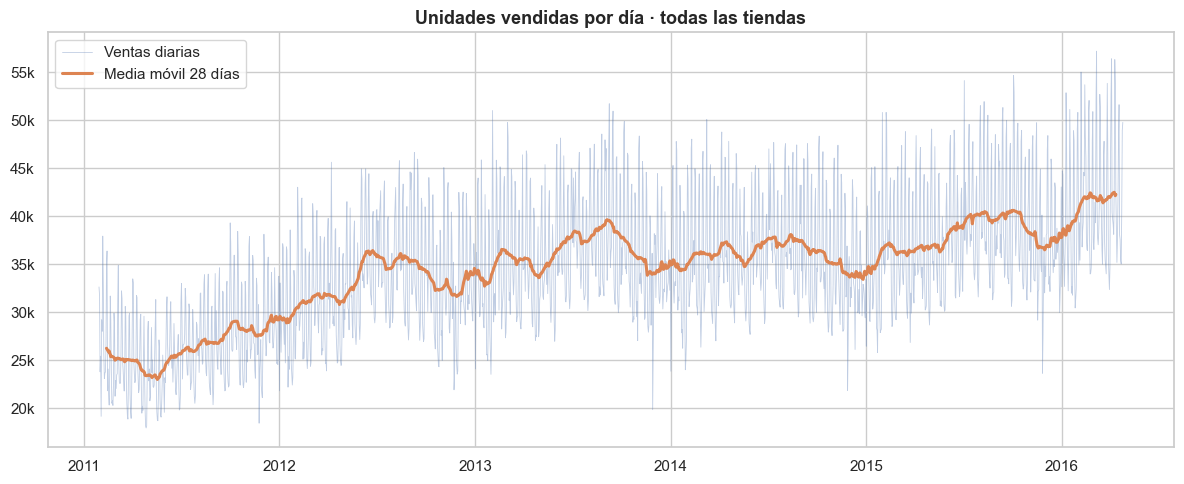

In [6]:
open_days = daily[~daily.closed].set_index("date")

fig, ax = plt.subplots()
ax.plot(open_days.index, open_days.units, lw=0.6, alpha=0.35, label="Ventas diarias")
ax.plot(open_days.index, open_days.units.rolling(28, center=True).mean(), lw=2.2, label="Media móvil 28 días")
ax.set_title("Unidades vendidas por día · todas las tiendas")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.legend()
plt.tight_layout(); plt.savefig(FIG_PATH / "01_evolucion.png", dpi=150); plt.show()

Para medir el crecimiento usamos solo **años completos (2012–2015)**. 2011 empieza el 29 de enero y 2016 acaba en abril, así que compararlos directamente daría crecimientos falsos. Ese era el error del análisis mensual anterior, que marcaba un +723 % en el primer mes.

In [7]:
full_years = daily[daily.year.between(2012, 2015)]
yearly = full_years.groupby("year").units.sum().to_frame("unidades")
yearly["crecimiento_%"] = yearly.unidades.pct_change() * 100
cagr = (yearly.unidades.iloc[-1] / yearly.unidades.iloc[0]) ** (1 / 3) - 1
print(f"Crecimiento anual compuesto 2012–2015: {cagr:.1%}")
yearly

Crecimiento anual compuesto 2012–2015: 4.6%


,unidades,crecimiento_%
year,,
2012,12061837,NaN
2013,13135753,8.90
2014,13089776,-0.35
2015,13800811,5.43


## 2. Estacionalidad semanal y anual

Expresamos cada día de la semana y cada mes como un **índice sobre la media (100 = día medio)**. Así se ve enseguida cuánto se desvía cada periodo. Excluimos los días cerrados y, para los meses, usamos solo años completos.

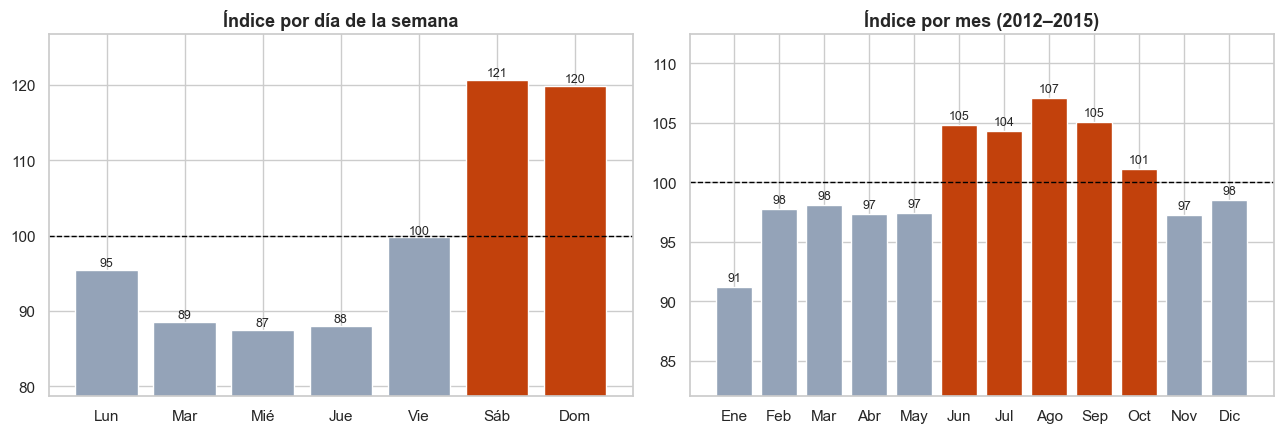

día,Lun,Mar,Mié,Jue,Vie,Sáb,Dom
índice,95.40,88.50,87.50,88.00,99.80,120.70,119.90


In [8]:
WEEKDAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
WEEKDAYS_ES = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
MONTHS_ES = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

od = daily[~daily.closed]
wd_index = (od.groupby("weekday").units.mean() / od.units.mean() * 100).reindex(WEEKDAYS)
fy = full_years[~full_years.closed]
m_index = fy.groupby("month").units.mean() / fy.units.mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, idx, labels, title in [(axes[0], wd_index, WEEKDAYS_ES, "Índice por día de la semana"),
                               (axes[1], m_index, MONTHS_ES, "Índice por mes (2012–2015)")]:
    colors = ["#c2410c" if v >= 100 else "#94a3b8" for v in idx]
    ax.bar(labels, idx.values, color=colors)
    ax.axhline(100, color="black", lw=1, ls="--")
    ax.set_ylim(idx.min() * 0.9, idx.max() * 1.05)
    ax.set_title(title)
    for i, v in enumerate(idx.values):
        ax.text(i, v + 0.5, f"{v:.0f}", ha="center", fontsize=9)
plt.tight_layout(); plt.savefig(FIG_PATH / "02_estacionalidad.png", dpi=150); plt.show()

pd.DataFrame({"día": WEEKDAYS_ES, "índice": wd_index.values.round(1)}).set_index("día").T

## 3. Impacto real de los eventos

Comparar la venta media de un día de evento con la media global engaña. Si el evento cae en domingo, ya vendería más solo por ser domingo. Por eso calculamos el **lift** de cada evento frente a una **línea base del mismo día de la semana**: la media de los 4 mismos días anteriores y los 4 posteriores, sin contar otros eventos ni días cerrados.

`lift = ventas del día de evento / línea base − 1`

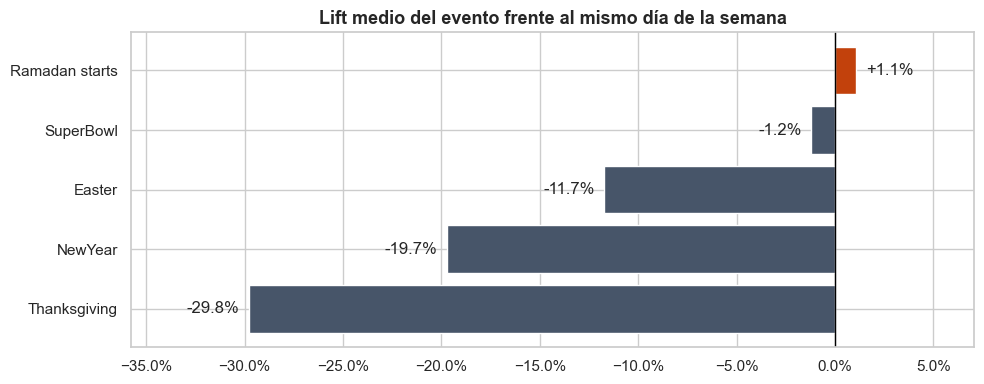

,mean,min,max,count
event,,,,
Thanksgiving,-29.80,-36.30,-23.90,5
NewYear,-19.70,-37.00,-10.20,5
Easter,-11.70,-20.10,-6.30,5
SuperBowl,-1.20,-7.90,9.00,6
Ramadan starts,1.10,-7.80,11.70,5


In [9]:
d_idx = daily.set_index("date")
valid = d_idx[~d_idx.closed & d_idx.event.isna()].units

rows = []
for date, row in d_idx[d_idx.event.notna()].iterrows():
    neighbours = [date + pd.Timedelta(weeks=k) for k in (-4, -3, -2, -1, 1, 2, 3, 4)]
    baseline = valid.reindex(neighbours).mean()
    rows.append({"event": row.event, "date": date, "units": row.units, "baseline": baseline,
                 "lift_%": (row.units / baseline - 1) * 100})
events = pd.DataFrame(rows)

event_lift = (events.groupby("event")["lift_%"].agg(["mean", "min", "max", "count"])
                    .sort_values("mean"))

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#c2410c" if v > 0 else "#475569" for v in event_lift["mean"]]
ax.barh(event_lift.index, event_lift["mean"], color=colors)
ax.axvline(0, color="black", lw=1)
ax.set_xlim(event_lift["mean"].min() - 6, max(event_lift["mean"].max(), 0) + 6)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Lift medio del evento frente al mismo día de la semana")
for i, v in enumerate(event_lift["mean"]):
    ax.text(v + (0.5 if v >= 0 else -0.5), i, f"{v:+.1f}%", va="center", ha="left" if v >= 0 else "right")
plt.tight_layout(); plt.savefig(FIG_PATH / "03_eventos.png", dpi=150); plt.show()

event_lift.round(1)

## 4. Tiendas y regiones

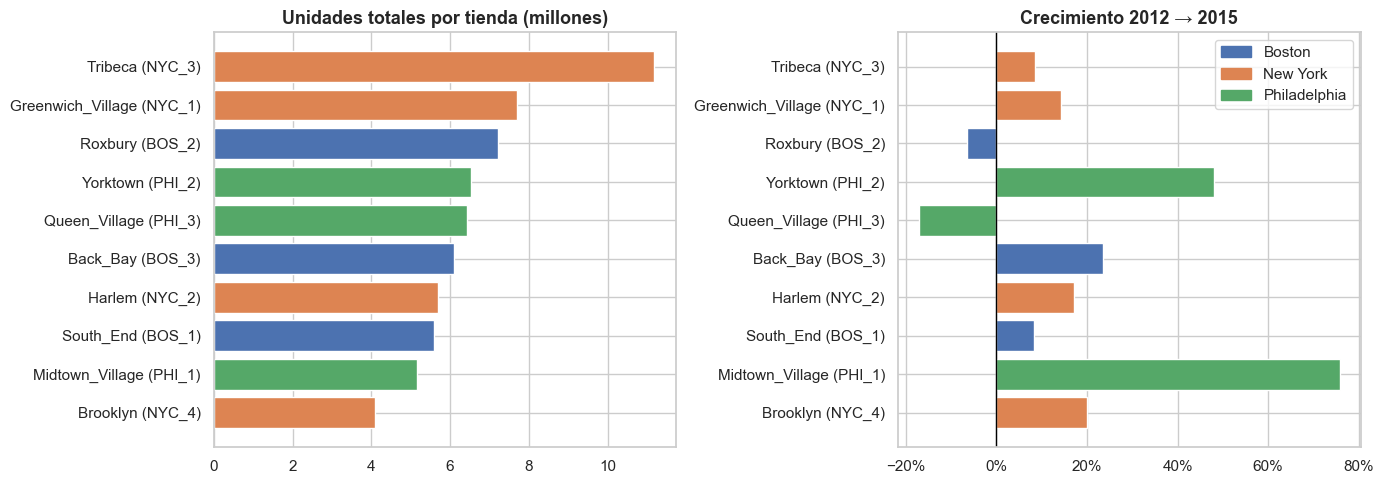

,2012,2015,unidades_total,crecimiento_12_15_%
region,,,,
Boston,3611531,3858923,18899006,6.90
New York,5268487,5967138,28675547,13.30
Philadelphia,3181819,3974750,18120856,24.90


unidades_total  crecimiento_12_15_%
region       store             store_code                                     
New York     Tribeca           NYC_3             11188180                 8.40
             Greenwich_Village NYC_1              7698216                14.30
Boston       Roxbury           BOS_2              7214384                -6.50
Philadelphia Yorktown          PHI_2              6544012                48.00
             Queen_Village     PHI_3              6427782               -17.10
Boston       Back_Bay          BOS_3              6089330                23.50
New York     Harlem            NYC_2              5685475                17.00
Boston       South_End         BOS_1              5595292                 8.20
Philadelphia Midtown_Village   PHI_1              5149062                75.80
New York     Brooklyn          NYC_4              4103676                19.90

In [10]:
by_year_store = pd.DataFrame(units, columns=calendar.year.values).T.groupby(level=0).sum().T
by_year_store[["store", "store_code", "region"]] = sales[["store", "store_code", "region"]].astype(str).values

stores = by_year_store.groupby(["region", "store", "store_code"])[[2012, 2015]].sum()
stores["unidades_total"] = sales.assign(t=units.sum(axis=1)).groupby(
    ["region", "store", "store_code"], observed=True).t.sum()
stores["crecimiento_12_15_%"] = (stores[2015] / stores[2012] - 1) * 100
stores = stores.sort_values("unidades_total", ascending=False)

regions = stores.groupby(level="region")[[2012, 2015, "unidades_total"]].sum()
regions["crecimiento_12_15_%"] = (regions[2015] / regions[2012] - 1) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
region_colors = dict(zip(regions.index, sns.color_palette("deep", len(regions))))
labels = [f"{s} ({c})" for _, s, c in stores.index]
axes[0].barh(labels[::-1], stores.unidades_total.values[::-1] / 1e6,
             color=[region_colors[r] for r, _, _ in stores.index][::-1])
axes[0].set_title("Unidades totales por tienda (millones)")
axes[1].barh(labels[::-1], stores["crecimiento_12_15_%"].values[::-1],
             color=[region_colors[r] for r, _, _ in stores.index][::-1])
axes[1].axvline(0, color="black", lw=1)
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title("Crecimiento 2012 → 2015")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in region_colors.values()]
axes[1].legend(handles, region_colors.keys(), loc="upper right")
plt.tight_layout(); plt.savefig(FIG_PATH / "04_tiendas.png", dpi=150); plt.show()

display(regions.round(1))
stores[["unidades_total", "crecimiento_12_15_%"]].round(1)

## 5. Categorías, departamentos e ingresos

Hasta ahora hemos contado **unidades**. Para hablar de negocio necesitamos **ingresos**, así que agregamos las ventas por semana y las multiplicamos por el precio de esa semana en esa tienda.

In [11]:
# Ventas semanales por serie (30.490 × 279) sin pasar por formato largo diario
week_of_day = calendar.yearweek.to_numpy()
weeks = np.unique(week_of_day)
weekly_units = np.stack([units[:, week_of_day == w].sum(axis=1) for w in weeks], axis=1).astype("int32")

weekly = pd.DataFrame(weekly_units, columns=weeks)
weekly.insert(0, "store_code", sales.store_code.astype(str).values)
weekly.insert(0, "item", sales.item.astype(str).values)
weekly = weekly.melt(id_vars=["item", "store_code"], var_name="yearweek", value_name="units")
weekly["yearweek"] = weekly.yearweek.astype("int32")

p = prices.assign(item=prices.item.astype(str), store_code=prices.store_code.astype(str))
weekly = weekly.merge(p[["item", "store_code", "yearweek", "sell_price"]],
                      on=["item", "store_code", "yearweek"], how="left")
weekly["revenue"] = weekly.units * weekly.sell_price

meta = sales[["item", "category", "department"]].drop_duplicates().astype(str)
weekly = weekly.merge(meta, on="item", how="left")

sin_precio = weekly.loc[weekly.sell_price.isna(), "units"].sum()
print(f"Filas semanales: {len(weekly):,}")
print(f"Unidades vendidas en semanas sin precio: {sin_precio:,} (el producto aún no estaba a la venta)")

Filas semanales: 8,506,710
Unidades vendidas en semanas sin precio: 0 (el producto aún no estaba a la venta)


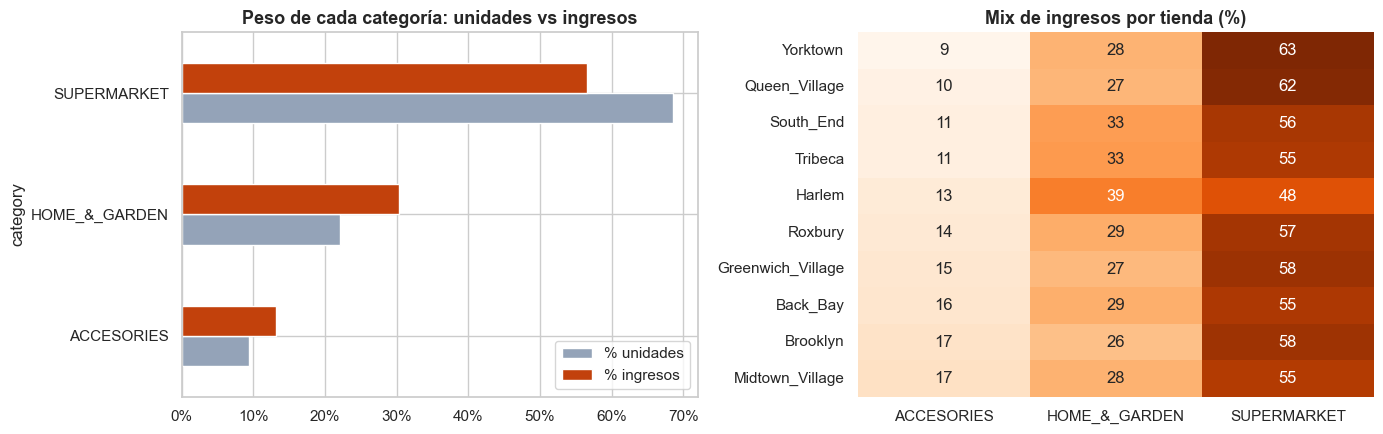

,unidades,ingresos,% unidades,% ingresos,precio_medio
category,,,,,
ACCESORIES,6124800,"30,348,479.10",9.30,13.10,5.00
HOME_&_GARDEN,14480670,"69,941,928.10",22.00,30.30,4.80
SUPERMARKET,45089939,"130,685,547.10",68.60,56.60,2.90


unidades      ingresos  % ingresos
category      department                                         
ACCESORIES    ACCESORIES_1      5596460 28,786,995.60       12.50
              ACCESORIES_2       528340  1,561,483.50        0.70
HOME_&_GARDEN HOME_&_GARDEN_1  11500526 51,577,409.30       22.30
              HOME_&_GARDEN_2   2980144 18,364,518.80        8.00
SUPERMARKET   SUPERMARKET_1     5088041 15,502,228.00        6.70
              SUPERMARKET_2     7629822 30,023,410.20       13.00
              SUPERMARKET_3    32372076 85,159,908.90       36.90

In [12]:
cat = weekly.groupby("category").agg(unidades=("units", "sum"), ingresos=("revenue", "sum"))
cat["% unidades"] = cat.unidades / cat.unidades.sum() * 100
cat["% ingresos"] = cat.ingresos / cat.ingresos.sum() * 100
cat["precio_medio"] = cat.ingresos / cat.unidades

dept = weekly.groupby(["category", "department"]).agg(unidades=("units", "sum"), ingresos=("revenue", "sum"))
dept["% ingresos"] = dept.ingresos / dept.ingresos.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
cat[["% unidades", "% ingresos"]].sort_values("% ingresos").plot.barh(ax=axes[0], color=["#94a3b8", "#c2410c"])
axes[0].set_title("Peso de cada categoría: unidades vs ingresos")
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())

mix = weekly.merge(sales[["store_code", "store"]].drop_duplicates().astype(str), on="store_code") \
            .pivot_table(index="store", columns="category", values="revenue", aggfunc="sum")
mix = mix.div(mix.sum(axis=1), axis=0) * 100
sns.heatmap(mix.sort_values(mix.columns[0]), annot=True, fmt=".0f", cmap="Oranges", ax=axes[1], cbar=False)
axes[1].set_title("Mix de ingresos por tienda (%)")
axes[1].set_xlabel(""); axes[1].set_ylabel("")
plt.tight_layout(); plt.savefig(FIG_PATH / "05_categorias.png", dpi=150); plt.show()

display(cat.round(1))
dept.round(1)

## 6. Precio y descuentos

**Precio entre productos.** Primero miramos si los productos caros se venden menos. Usamos la correlación de **Spearman**, que mide relaciones monótonas y aguanta mejor los valores extremos que Pearson.

**Descuentos dentro de un mismo producto.** Lo interesante para el negocio es otra pregunta: cuando **un mismo producto** baja de precio, ¿vende más? Para cada producto y tienda comparamos el precio de cada semana con su precio habitual (la mediana) y medimos cuánto se desvían las ventas de su media.

Spearman precio medio vs unidades semanales medias: rho = -0.42 (p = 0.0e+00)


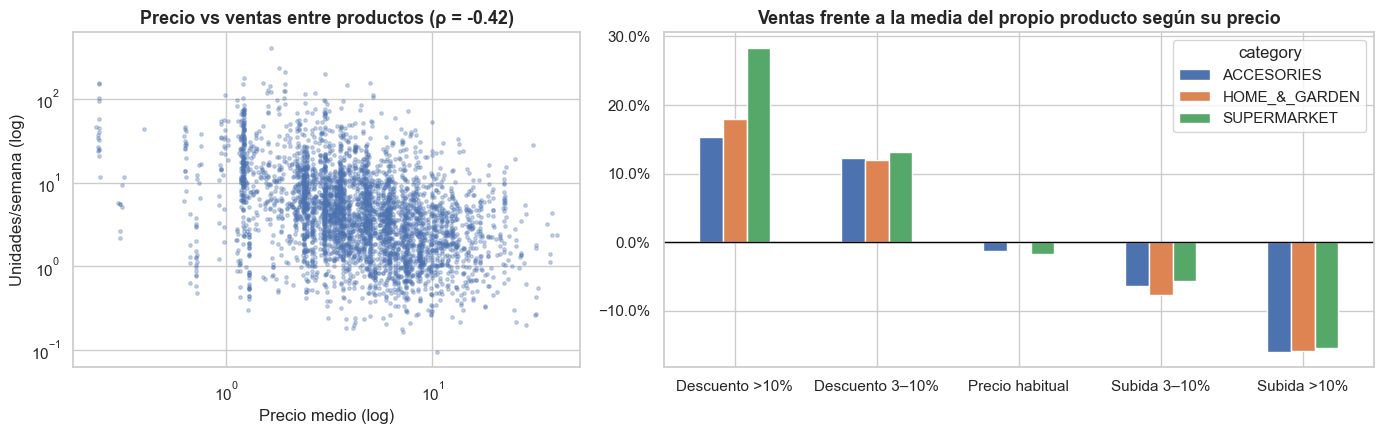

,% de semanas
tramo_precio,
Descuento >10%,3.90
Descuento 3–10%,6.70
Precio habitual,79.10
Subida 3–10%,6.60
Subida >10%,3.70


category,ACCESORIES,HOME_&_GARDEN,SUPERMARKET
tramo_precio,,,
Descuento >10%,15.30,18.00,28.40
Descuento 3–10%,12.30,12.00,13.20
Precio habitual,-1.30,-0.10,-1.60
Subida 3–10%,-6.40,-7.70,-5.70
Subida >10%,-16.00,-15.80,-15.40


In [13]:
on_sale = weekly[weekly.sell_price.notna()].copy()
per_series = on_sale.groupby(["item", "store_code"]).agg(price=("sell_price", "mean"), units=("units", "mean"))
rho, pval = spearmanr(per_series.price, per_series.units)
print(f"Spearman precio medio vs unidades semanales medias: rho = {rho:.2f} (p = {pval:.1e})")

g = on_sale.groupby(["item", "store_code"])
on_sale["rel_price"] = on_sale.sell_price / g.sell_price.transform("median")
on_sale["rel_units"] = on_sale.units / g.units.transform("mean")
on_sale = on_sale[np.isfinite(on_sale.rel_units)]

bins = [0, 0.90, 0.97, 1.03, 1.10, np.inf]
labels_b = ["Descuento >10%", "Descuento 3–10%", "Precio habitual", "Subida 3–10%", "Subida >10%"]
on_sale["tramo_precio"] = pd.cut(on_sale.rel_price, bins=bins, labels=labels_b)

promo = (on_sale.groupby(["tramo_precio", "category"], observed=True).rel_units.mean().unstack() - 1) * 100
share = on_sale.tramo_precio.value_counts(normalize=True).reindex(labels_b) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={"width_ratios": [1, 1.4]})
sample = per_series.sample(4000, random_state=RANDOM_STATE)
axes[0].scatter(sample.price, sample.units, s=6, alpha=0.3)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("Precio medio (log)"); axes[0].set_ylabel("Unidades/semana (log)")
axes[0].set_title(f"Precio vs ventas entre productos (ρ = {rho:.2f})")
promo.plot.bar(ax=axes[1], rot=0)
axes[1].axhline(0, color="black", lw=1)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title("Ventas frente a la media del propio producto según su precio")
axes[1].set_xlabel("")
plt.tight_layout(); plt.savefig(FIG_PATH / "06_precio.png", dpi=150); plt.show()

display(share.round(1).to_frame("% de semanas"))
promo.round(1)

## 7. Concentración del catálogo (Pareto)

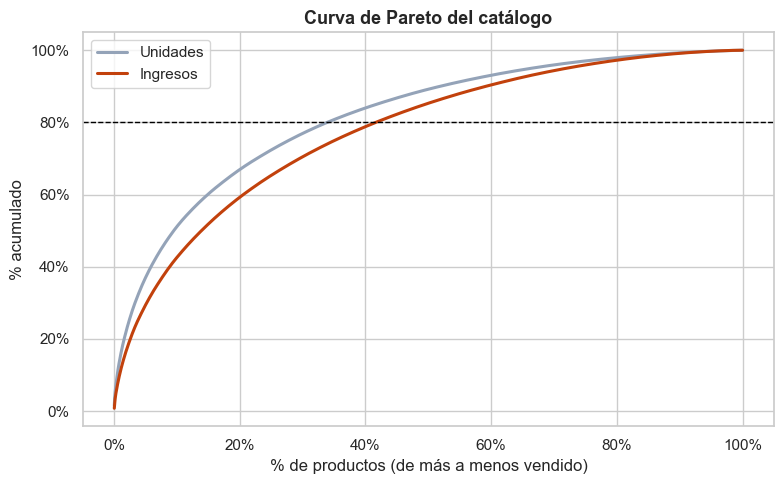

El 33.9% de los productos genera el 80% de las unidades
El 41.7% de los productos genera el 80% de los ingresos
Productos sin ninguna venta en las últimas 8 semanas en ninguna tienda: 14


In [14]:
item_rev = weekly.groupby("item").agg(unidades=("units", "sum"), ingresos=("revenue", "sum"))

def pct_for_80(s):
    s = s.sort_values(ascending=False)
    return ((s.cumsum() / s.sum()) < 0.8).mean() * 100 + 100 / len(s)

p80_units, p80_rev = pct_for_80(item_rev.unidades), pct_for_80(item_rev.ingresos)

fig, ax = plt.subplots(figsize=(8, 5))
for col, color in [("unidades", "#94a3b8"), ("ingresos", "#c2410c")]:
    s = item_rev[col].sort_values(ascending=False)
    ax.plot(np.arange(1, len(s) + 1) / len(s) * 100, s.cumsum() / s.sum() * 100, lw=2.2, color=color, label=col.capitalize())
ax.axhline(80, ls="--", color="black", lw=1)
ax.xaxis.set_major_formatter(mtick.PercentFormatter()); ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel("% de productos (de más a menos vendido)"); ax.set_ylabel("% acumulado")
ax.set_title("Curva de Pareto del catálogo")
ax.legend()
plt.tight_layout(); plt.savefig(FIG_PATH / "07_pareto.png", dpi=150); plt.show()

last_8w = units[:, -56:].sum(axis=1)
item_recent = pd.Series(last_8w, index=sales.item.astype(str)).groupby(level=0).sum()
inactivos = (item_recent == 0).sum()

print(f"El {p80_units:.1f}% de los productos genera el 80% de las unidades")
print(f"El {p80_rev:.1f}% de los productos genera el 80% de los ingresos")
print(f"Productos sin ninguna venta en las últimas 8 semanas en ninguna tienda: {inactivos}")

## 8. Demanda intermitente

El **68% de las celdas de ventas son cero**. La mayoría de productos no se venden todos los días en todas las tiendas, y esto condiciona cómo se deben predecir.

Clasificamos cada serie (producto × tienda) con el método de **Syntetos-Boylan**, estándar en planificación de la demanda. Se calcula desde la primera venta de cada serie:
- **ADI**, intervalo medio entre días con venta: indica con qué frecuencia se vende.
- **CV²**, variabilidad al cuadrado de las cantidades cuando hay venta: indica lo irregular que es.

| | CV² < 0,49 | CV² ≥ 0,49 |
|---|---|---|
| **ADI < 1,32** | Suave | Errática |
| **ADI ≥ 1,32** | Intermitente | Irregular (*lumpy*) |

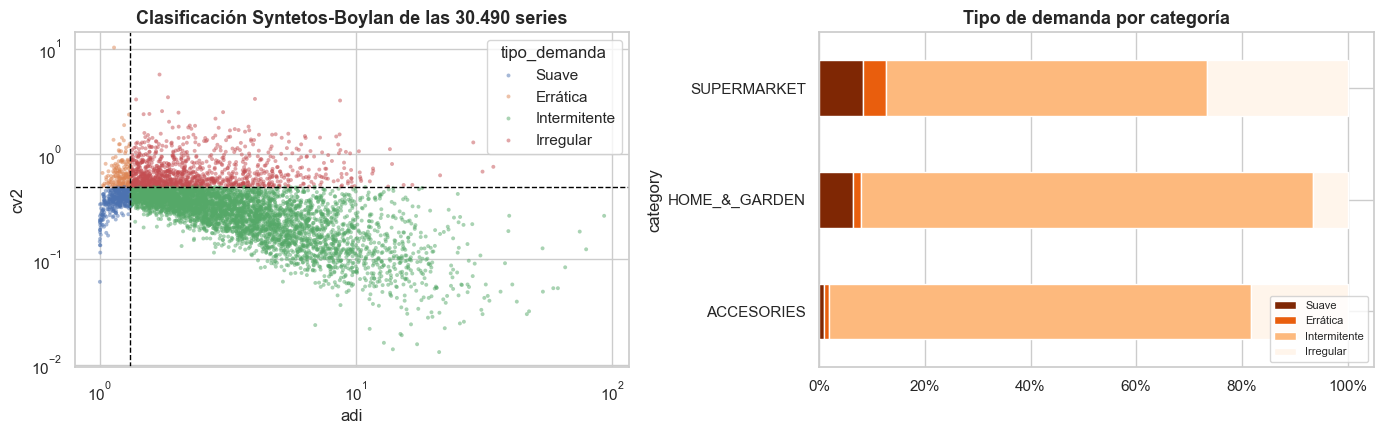

,% de series
tipo_demanda,
Suave,6.20
Errática,2.80
Intermitente,72.80
Irregular,18.20


tipo_demanda,Suave,Errática,Intermitente,Irregular
category,,,,
ACCESORIES,0.80,1.00,79.90,18.30
HOME_&_GARDEN,6.30,1.50,85.50,6.60
SUPERMARKET,8.20,4.50,60.70,26.60


In [15]:
def demand_profile(mat):
    mat = mat.astype("float32")
    started = np.maximum.accumulate(mat > 0, axis=1)           # desde la primera venta
    active_days = started.sum(axis=1)
    nz = mat > 0
    n_nz = nz.sum(axis=1)
    adi = np.divide(active_days, n_nz, out=np.full(len(mat), np.nan), where=n_nz > 0)
    nz_vals = np.where(nz, mat, np.nan)
    mean_nz = np.nanmean(nz_vals, axis=1)
    cv2 = (np.nanstd(nz_vals, axis=1) / mean_nz) ** 2
    zero_share = 1 - n_nz / np.maximum(active_days, 1)
    return adi, cv2, zero_share, active_days

adi, cv2, zero_share, active_days = demand_profile(units)
series = sales[["id", "item", "category", "store_code"]].astype(str).copy()
series["adi"], series["cv2"], series["zero_share"] = adi, cv2, zero_share
series = series.dropna(subset=["adi"])

def sb_class(r):
    if r.adi < 1.32:
        return "Suave" if r.cv2 < 0.49 else "Errática"
    return "Intermitente" if r.cv2 < 0.49 else "Irregular"

series["tipo_demanda"] = series.apply(sb_class, axis=1)
ORDER = ["Suave", "Errática", "Intermitente", "Irregular"]

tab = pd.crosstab(series.category, series.tipo_demanda, normalize="index")[ORDER] * 100
total = series.tipo_demanda.value_counts(normalize=True).reindex(ORDER) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
s = series.sample(6000, random_state=RANDOM_STATE)
sns.scatterplot(data=s, x="adi", y="cv2", hue="tipo_demanda", hue_order=ORDER, s=8, alpha=0.5, ax=axes[0], linewidth=0)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].axvline(1.32, color="black", lw=1, ls="--"); axes[0].axhline(0.49, color="black", lw=1, ls="--")
axes[0].set_title("Clasificación Syntetos-Boylan de las 30.490 series")
tab.plot.barh(stacked=True, ax=axes[1], colormap="Oranges_r", edgecolor="white")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title("Tipo de demanda por categoría")
axes[1].legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.savefig(FIG_PATH / "08_demanda.png", dpi=150); plt.show()

display(total.round(1).to_frame("% de series"))
tab.round(1)

## 9. Segmentación de productos (K-Means)

El clustering original usaba media, desviación y suma de ventas. Pero la **suma y la media son la misma información**, porque una es la otra multiplicada por el número de días. Además, el número de clusters se había elegido sin justificar.

Ahora construimos, para cada producto, variables que describen **cómo** se vende, no solo **cuánto**:

| Variable | Qué mide |
|---|---|
| `log_units` | Volumen: unidades diarias medias (en log, para que los superventas no dominen) |
| `zero_share` | Intermitencia: % de días sin venta |
| `cv2` | Irregularidad de las cantidades vendidas |
| `trend` | Tendencia: último año frente al anterior (log del ratio) |
| `log_price` | Precio medio |
| `weekend_share` | Dependencia del fin de semana (1 = normal) |

El número de clusters se elige con el **método del codo** y el **coeficiente de silueta**.

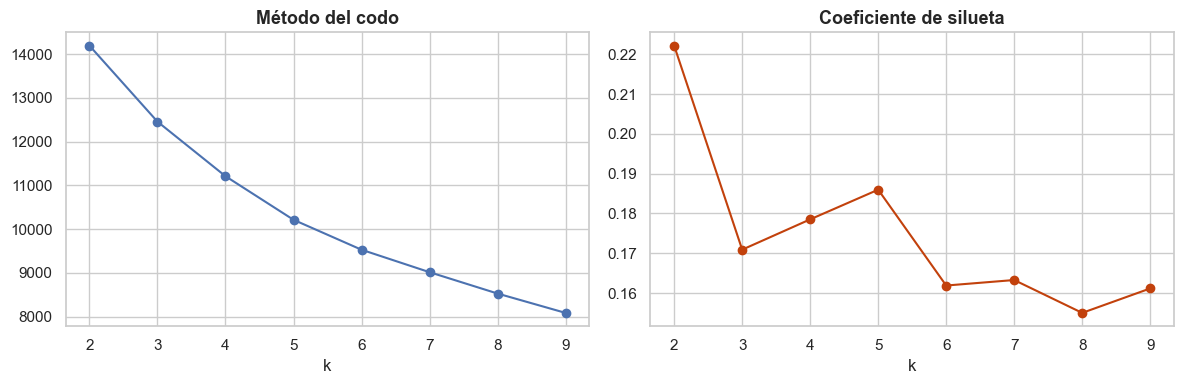

k,2,3,4,5,6,7,8,9
inercia,"14,189.95","12,454.67","11,209.18","10,214.13","9,530.28","9,017.45","8,529.85","8,087.77"
silueta,0.22,0.17,0.18,0.19,0.16,0.16,0.15,0.16


In [16]:
item_units = pd.DataFrame(units, index=sales.item.astype(str)).groupby(level=0).sum()
item_mat = item_units.to_numpy()
i_adi, i_cv2, i_zero, i_active = demand_profile(item_mat)

started = np.maximum.accumulate(item_mat > 0, axis=1)
mean_units = (item_mat * started).sum(axis=1) / np.maximum(started.sum(axis=1), 1)

last_year, prev_year = item_mat[:, -364:].sum(axis=1), item_mat[:, -728:-364].sum(axis=1)
trend = np.log((last_year + 1) / (prev_year + 1))

is_weekend = calendar.weekday.isin(["Saturday", "Sunday"]).to_numpy()
weekend_share = (item_mat[:, is_weekend].sum(axis=1) / np.maximum(item_mat.sum(axis=1), 1)) / is_weekend.mean()

price_item = weekly.groupby("item").sell_price.mean()

features = pd.DataFrame({
    "log_units": np.log1p(mean_units),
    "zero_share": i_zero,
    "cv2": np.log1p(i_cv2),
    "trend": np.clip(trend, -2, 2),
    "log_price": np.log(price_item.reindex(item_units.index).to_numpy()),
    "weekend_share": weekend_share,
}, index=item_units.index).dropna()

X = StandardScaler().fit_transform(features)

ks = range(2, 10)
inertia, silhouette = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(ks), inertia, marker="o"); axes[0].set_title("Método del codo"); axes[0].set_xlabel("k")
axes[1].plot(list(ks), silhouette, marker="o", color="#c2410c"); axes[1].set_title("Coeficiente de silueta"); axes[1].set_xlabel("k")
plt.tight_layout(); plt.show()

pd.DataFrame({"k": list(ks), "inercia": inertia, "silueta": silhouette}).set_index("k").round(3).T

In [17]:
K = 5
km = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10).fit(X)
features["cluster"] = km.labels_

item_value = item_rev.reindex(features.index)
profile = features.groupby("cluster").agg(
    productos=("log_units", "size"),
    unidades_dia=("log_units", lambda s: np.expm1(s).median()),
    dias_sin_venta_pct=("zero_share", lambda s: s.median() * 100),
    tendencia_pct=("trend", lambda s: (np.exp(s.median()) - 1) * 100),
    precio_medio=("log_price", lambda s: np.exp(s).median()),
    finde=("weekend_share", "median"),
)
profile["% ingresos"] = item_value.groupby(features.cluster).ingresos.sum() / item_value.ingresos.sum() * 100
profile["categoría principal"] = features.join(meta.set_index("item")).groupby("cluster").category.agg(lambda s: s.mode()[0])
profile.round(2)

,productos,unidades_dia,dias_sin_venta_pct,tendencia_pct,precio_medio,finde,% ingresos,categoría principal
cluster,,,,,,,,
0,358,3.69,19.28,10.76,3.05,1.12,4.87,SUPERMARKET
1,237,4.95,21.43,174.66,4.52,1.23,5.61,SUPERMARKET
2,534,1.78,31.66,9.88,7.36,1.24,7.38,HOME_&_GARDEN
3,726,21.45,1.99,4.49,2.35,1.19,39.92,SUPERMARKET
4,1194,6.31,6.28,6.13,5.19,1.23,42.22,SUPERMARKET


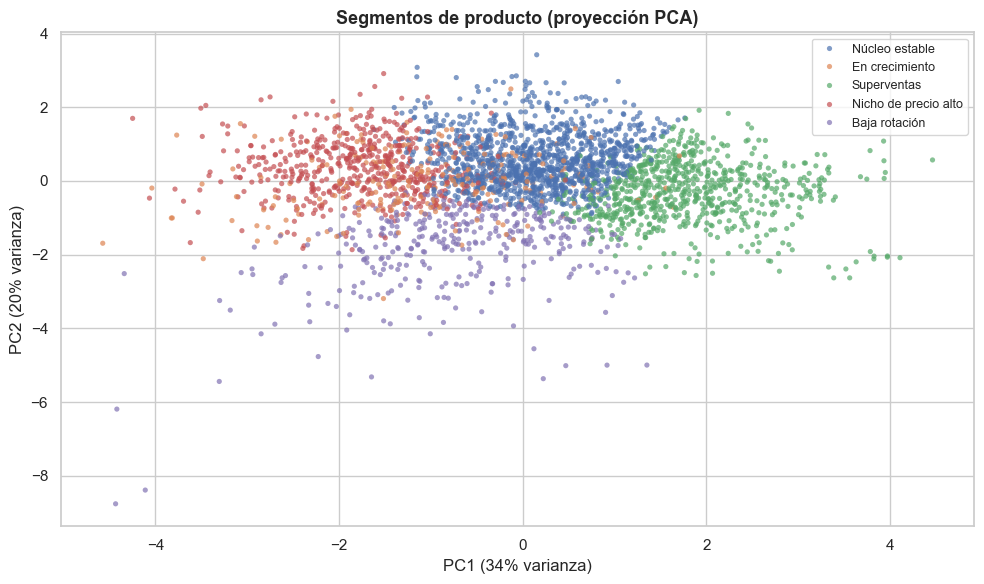

,productos,unidades_dia,dias_sin_venta_pct,tendencia_pct,precio_medio,finde,% ingresos,categoría principal
cluster,,,,,,,,
Baja rotación,358,3.69,19.28,10.76,3.05,1.12,4.87,SUPERMARKET
En crecimiento,237,4.95,21.43,174.66,4.52,1.23,5.61,SUPERMARKET
Nicho de precio alto,534,1.78,31.66,9.88,7.36,1.24,7.38,HOME_&_GARDEN
Superventas,726,21.45,1.99,4.49,2.35,1.19,39.92,SUPERMARKET
Núcleo estable,1194,6.31,6.28,6.13,5.19,1.23,42.22,SUPERMARKET


In [18]:
# Nombres asignados por reglas sobre el perfil, para que no dependan del número de cluster
names, rest = {}, profile.copy()
def take(idx, name):
    global rest
    names[idx] = name
    rest = rest.drop(idx)
take(rest.unidades_dia.idxmax(), "Superventas")
take(rest.tendencia_pct.idxmax(), "En crecimiento")
take(rest.precio_medio.idxmax(), "Nicho de precio alto")
take(rest.unidades_dia.idxmax(), "Núcleo estable")
take(rest.index[0], "Baja rotación")
names

features["segmento"] = features.cluster.map(names)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=features.segmento, s=14, alpha=0.7, ax=ax, linewidth=0)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} varianza)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} varianza)")
ax.set_title("Segmentos de producto (proyección PCA)")
ax.legend(title="", fontsize=9)
plt.tight_layout(); plt.savefig(FIG_PATH / "09_clusters.png", dpi=150); plt.show()

profile.rename(index=names).round(2)

## 10. Conclusiones y recomendaciones

**1. El fin de semana es la palanca principal, no los festivos.**
El sábado y el domingo venden un 20% más que el día medio. Los grandes festivos (Acción de Gracias, Año Nuevo y Pascua) **reducen** las ventas entre un 12% y un 30%. El análisis anterior decía lo contrario porque comparaba con la media global sin tener en cuenta el día de la semana.
→ *Reforzar reposición y personal en fin de semana y ajustar a la baja los pedidos y turnos en esos festivos.*

**2. Crecimiento desigual entre tiendas.**
Filadelfia crece un 25% (Midtown Village +76% y Yorktown +48%), mientras que Queen Village cae un 17% y Roxbury un 7%.
→ *Investigar qué funciona en Midtown Village (surtido, precios, ubicación) y revisar Queen Village y Roxbury.*

**3. Los descuentos funcionan, sobre todo en alimentación.**
Una rebaja de más del 10% sube las ventas un 28% en SUPERMARKET y un 15–18% en el resto. Solo el 4% de las semanas tiene un descuento así.
→ *Hay margen para promociones más frecuentes y bien dirigidas en SUPERMARKET, siempre comprobando que el aumento de volumen compensa el margen perdido.*

**4. El catálogo está concentrado, pero no tanto como un 80/20 puro.**
El 34% de los productos hace el 80% del volumen. Solo 14 productos no han vendido nada en las últimas 8 semanas en ninguna tienda.
→ *Revisar esos 14 productos para posible descatalogación y proteger el stock de Superventas.*

**5. Cada segmento necesita una gestión distinta.**
| Segmento | Gestión recomendada |
|---|---|
| Superventas | Nunca sin stock: reposición automática y previsión diaria |
| Núcleo estable | Previsión semanal estándar; es el grueso de los ingresos |
| En crecimiento | Seguimiento mensual y ampliar su presencia en tienda si mantienen la tendencia |
| Nicho de precio alto | Stock mínimo por tienda y centralizar el inventario |
| Baja rotación | Candidatos a racionalizar el surtido |

**6. La previsión debe tratar la intermitencia.**
El 73% de las series son intermitentes: en la mayoría de días no hay venta. Un modelo que prediga "la media" sobreestimará casi siempre, así que hacen falta métodos específicos.

> **Limitaciones:** el coeficiente de silueta del clustering es moderado (≈0,19), así que los segmentos son una guía de gestión y no grupos totalmente separados. El efecto de los descuentos es observacional: puede haber otros factores que coincidan con las rebajas.


### Próximos pasos
- **Modelo de previsión** por producto y tienda: LightGBM con variables de calendario, eventos, precio relativo y retardos, y métodos específicos (Croston/TSB) para las series intermitentes.
- **Simulador de descuentos** que use el lift medido para estimar el impacto de una promoción antes de lanzarla.
- **Cuadro de mando** con la segmentación actualizada cada mes.